In [1]:
import pandas as pd
import numpy as np

In [2]:
# Carga de URL del dataset
url = 'https://raw.githubusercontent.com/Cristian-Eric-Falco/siniestros_viales_datos/refs/heads/main/siniestros_viales_hechos.csv'

# Leemos el dataset
df = pd.read_csv(url)


In [3]:
# Muestra las primeras 5 filas
display(df.head())

,id_siniestro,numero_total_de_victimas,numero_victimas_leve_siniestro,numero_victimas_grave_siniestro,numero_victimas_mortal_siniestro,fecha_siniestro,anio_siniestro,mes_siniestro,dia_siniestro,hora_siniestro,...,direccion_normalizada_siniestro,comuna_siniestro,tipo_de_via_siniestro,geocodificacion_plana,longitud_siniestro,latitud_siniestro,participantes_siniestro,modo_desplazamiento_victima,contraparte_siniestro,gravedad_siniestro
0,LC-2019-0000445,3,3,0,0,2019-01-01,2019,1,1,13:40:00,...,NaN,Comuna 11,NaN,POINT (94371.44237885093025398 102884.19365105...,-58.524662,-34.603255,AUTO-AUTO,AUTO,AUTO,LEVE
1,LC-2019-0000194,1,1,0,0,2019-01-01,2019,1,1,07:15:00,...,NaN,Comuna 9,NaN,POINT (94030.76669932194636203 97681.071761248...,-58.528413,-34.650156,AUTO-CAMION,AUTO,CAMION,LEVE
2,LC-2019-0000329,1,1,0,0,2019-01-01,2019,1,1,12:24:00,...,NaN,Comuna 4,NaN,POINT (105367.86665769023238681 97877.75085908...,-58.404748,-34.648387,AUTO-MOVIL,AUTO,MOVIL,LEVE
3,LC-2019-0000082,4,4,0,0,2019-01-01,2019,1,1,04:30:00,...,NaN,Comuna 3,NaN,POINT (105968.98286849579017144 102737.1734686...,-58.398225,-34.604579,AUTO-TRANSPORTE PUBLICO,AUTO,TRANSPORTE PUBLICO,LEVE
4,LC-2019-0000053,1,1,0,0,2019-01-01,2019,1,1,01:55:00,...,NaN,Comuna 8,AUTOPISTA,POINT (101813.84712503915943671 95578.55507230...,-58.443510,-34.669125,AUTO-UTILITARIO,AUTO,UTILITARIO,LEVE


Asignamos en una variable las columnas categoricas, ya que sobre ellas realizaremos varias transformaciones

In [4]:
columnas_cat = ['comuna_siniestro', 'tipo_de_via_siniestro', 'participantes_siniestro', 'modo_desplazamiento_victima','contraparte_siniestro','gravedad_siniestro']


In [5]:
# Mostrar tipo y cantidad de datos
print("\nData types:")
display(df.info())


Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54064 entries, 0 to 54063
Data columns (total 21 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id_siniestro                      54064 non-null  object 
 1   numero_total_de_victimas          54064 non-null  int64  
 2   numero_victimas_leve_siniestro    54064 non-null  int64  
 3   numero_victimas_grave_siniestro   54064 non-null  int64  
 4   numero_victimas_mortal_siniestro  54064 non-null  int64  
 5   fecha_siniestro                   54064 non-null  object 
 6   anio_siniestro                    54064 non-null  int64  
 7   mes_siniestro                     54064 non-null  int64  
 8   dia_siniestro                     54064 non-null  int64  
 9   hora_siniestro                    53987 non-null  object 
 10  rango_horario                     53987 non-null  float64
 11  direccion_normalizada_siniestro   41164 non-null  obje

None

In [6]:
def mostrar_valores_unicos(df, columnas):
    print("--- INSPECCIÓN DE VALORES ÚNICOS EN COLUMNAS CATEGÓRICAS ---")
    for col in columnas:
        # .unique() extrae solo los valores distintos (incluyendo NaN)
        valores_distintos = df[col].unique()

        print(f"\nValores únicos para la columna '{col}':")
        # Lo convertimos a lista para que la visualización en consola sea más limpia
        print(list(valores_distintos))


# Llamamos a la función
mostrar_valores_unicos(df, columnas_cat)

--- INSPECCIÓN DE VALORES ÚNICOS EN COLUMNAS CATEGÓRICAS ---

Valores únicos para la columna 'comuna_siniestro':
['Comuna 11', 'Comuna 9', 'Comuna 4', 'Comuna 3', 'Comuna 8', 'Comuna 14', 'Comuna 12', 'Comuna 15', 'Comuna 1', 'Comuna 7', 'Comuna 2', 'Comuna 13', 'Comuna 5', 'Comuna 6', 'Comuna 10', nan, 'COMUNA 1', 'COMUNA 3', 'COMUNA 15']

Valores únicos para la columna 'tipo_de_via_siniestro':
[nan, 'AUTOPISTA', 'AVENIDA', 'CALLE', 'AV. GRAL. PAZ']

Valores únicos para la columna 'participantes_siniestro':
['AUTO-AUTO', 'AUTO-CAMION', 'AUTO-MOVIL', 'AUTO-TRANSPORTE PUBLICO', 'AUTO-UTILITARIO', 'BICICLETA-AUTO', 'MOTO-AUTO', 'PEATON-AUTO', 'PEATON-MOTO', 'PEATON-TRANSPORTE PUBLICO', 'SD-SD', 'TAXI-TRANSPORTE PUBLICO', 'BICICLETA-TAXI', 'CAMION-TRANSPORTE PUBLICO', 'PEATON-CAMION', 'TAXI-TAXI', 'TRANSPORTE PUBLICO-TRANSPORTE PUBLICO', 'MOTO-CAMION', 'MOTO-UTILITARIO', 'PEATON-TAXI', 'PEATON-UTILITARIO', 'TAXI-AUTO', 'AUTO-TAXI', 'MOTO-MOTO', 'MOTO-MOVIL', 'TRANSPORTE PUBLICO-AUTO', 'BI

In [7]:
df['tipo_de_via_siniestro'] = df['tipo_de_via_siniestro'].replace('AV. GRAL. PAZ', 'AUTOPISTA')

In [8]:
def estandarizar_registros(df, columnas_categoricas):
    """
    Estandariza columnas categóricas a mayúsculas y sin espacios,
    manejando todas las mutaciones de valores nulos.
    """
    df_clean = df.copy()

    for col in columnas_categoricas:
        if col in df_clean.columns:
            # 1. Convertimos a texto, a mayúsculas y quitamos espacios
            df_clean[col] = df_clean[col].astype(str).str.upper().str.strip()

            # 2. Lista extensa de todas las formas en que un "nulo" puede estar escrito o haberse transformado
            variantes_nulos = ['NAN', 'NONE', '<NA>', 'NULL', 'ND', '']

            # 3. Reemplazamos todas esas palabras de texto por el verdadero nulo matemático
            df_clean[col] = df_clean[col].replace(variantes_nulos, np.nan)

    return df_clean

# --- Ejecución ---
df = estandarizar_registros(df, columnas_cat)

DETECCION DE VALORES NULOS

In [9]:
def detectar_valores_sd(df):
    """Cuenta la cantidad de valores 'SD' en columnas de tipo texto."""
    print("--- Conteo de valores 'SD' por columna ---")
    sd_totales = 0
    for column in df.select_dtypes(include=['object']).columns:
        sd_count = (df[column] == 'SD').sum()
        if sd_count > 0:
            print(f"Columna '{column}': {sd_count} registros con 'SD'")
            sd_totales += sd_count
    if sd_totales == 0:
        print("No se encontraron valores 'SD'.")
    print("-" * 40)

def identificar_duplicados(df, columna_id):
    """Identifica y muestra registros duplicados basados en una columna."""
    duplicados = df[df.duplicated(subset=[columna_id], keep=False)]
    if not duplicados.empty:
        print(f"--- Se encontraron {len(duplicados)} registros con '{columna_id}' duplicado ---")
        display(duplicados.sort_values(by=columna_id).head()) # Mostramos solo los primeros para no saturar
    else:
        print(f"--- No hay valores duplicados en la columna '{columna_id}' ---")

def estandarizar_nulos_y_tipos(df):
    # 1. Aislamos solo las columnas de texto para evitar que Pandas falle
    # silenciosamente al chocar con números o fechas
    cols_texto = df.select_dtypes(include=['object', 'string']).columns

    # 2. Reemplazamos directamente sobre esas columnas (sin regex, más rápido y seguro)
    # Incluimos variaciones comunes de espacios o mayúsculas por precaución
    variantes_sd = ['SD', 'SD ', ' SD', 'sd', 'Sd']
    df[cols_texto] = df[cols_texto].replace(variantes_sd, np.nan)

    # 3. Conversiones de tipos
    if 'edad_victima' in df.columns:
        df['edad_victima'] = pd.to_numeric(df['edad_victima'], errors='coerce')

    if 'fecha_siniestro' in df.columns:
        df['fecha_siniestro'] = pd.to_datetime(df['fecha_siniestro'], errors='coerce')

    return df


In [10]:
print("=== FASE 1: ANÁLISIS INICIAL (DATOS CRUDOS) ===")
detectar_valores_sd(df)
identificar_duplicados(df, 'id_siniestro')

print("\n=== FASE 2: TRANSFORMACIÓN Y LIMPIEZA ===")
# Aplicamos la estandarización aislando los textos y reasignamos al DataFrame
df_limpio = estandarizar_nulos_y_tipos(df)
print("Transformación de tipos y limpieza de 'SD' completada.")

print("\n=== FASE 3: VERIFICACIÓN POST-PROCESAMIENTO ===")
# 3.1 Verificamos que el reemplazo funcionó (debería decir que no hay 'SD')
print("-> Re-evaluando valores 'SD':")
detectar_valores_sd(df_limpio)

# 3.2 Revisamos que los tipos de datos (como el float/Int64 de la edad o el datetime) estén correctos
print("\n-> Tipos de datos actualizados:")
display(df_limpio.info())

# 3.3 Verificamos la cantidad total de nulos (NaN) reales con los que vas a trabajar
print("\n-> Conteo final de nulos (NaN) por columna:")
display(df_limpio.isnull().sum())

=== FASE 1: ANÁLISIS INICIAL (DATOS CRUDOS) ===
--- Conteo de valores 'SD' por columna ---
Columna 'modo_desplazamiento_victima': 9564 registros con 'SD'
Columna 'contraparte_siniestro': 12686 registros con 'SD'
----------------------------------------
--- No hay valores duplicados en la columna 'id_siniestro' ---

=== FASE 2: TRANSFORMACIÓN Y LIMPIEZA ===
Transformación de tipos y limpieza de 'SD' completada.

=== FASE 3: VERIFICACIÓN POST-PROCESAMIENTO ===
-> Re-evaluando valores 'SD':
--- Conteo de valores 'SD' por columna ---
No se encontraron valores 'SD'.
----------------------------------------

-> Tipos de datos actualizados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54064 entries, 0 to 54063
Data columns (total 21 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   id_siniestro                      54064 non-null  object        
 1   numero_total_de_victimas          

None


-> Conteo final de nulos (NaN) por columna:


,0
id_siniestro,0
numero_total_de_victimas,0
numero_victimas_leve_siniestro,0
numero_victimas_grave_siniestro,0
numero_victimas_mortal_siniestro,0
fecha_siniestro,0
anio_siniestro,0
mes_siniestro,0
dia_siniestro,0
hora_siniestro,77


BUSQUEDA DE VALORES DUPLICADOS

In [11]:
def identificar_duplicados(df, columna_id):
    """
    Identifica registros duplicados diferenciando entre filas idénticas
    y colisiones de ID (mismo accidente, múltiples víctimas).
    """
    # 1. Buscamos duplicados donde TODA la fila es exactamente igual (Error de carga)
    duplicados_exactos = df[df.duplicated(keep=False)]

    # 2. Buscamos duplicados solo por el ID del siniestro
    duplicados_id = df[df.duplicated(subset=[columna_id], keep=False)]

    print("--- ANÁLISIS DE DUPLICADOS ---")

    if not duplicados_exactos.empty:
        print(f"ALERTA: Se encontraron {len(duplicados_exactos)} filas EXACTAMENTE idénticas (posible error de sistema/carga).")
    else:
        print("No hay filas 100% duplicadas.")

    if not duplicados_id.empty:
        ids_unicos_repetidos = duplicados_id[columna_id].nunique()
        print(f"INFO: Hay {len(duplicados_id)} registros compartiendo {ids_unicos_repetidos} IDs de siniestro únicos.")
        print("    (Esto es normal si hay siniestros con múltiples víctimas).")
        print("\nEjemplo de un siniestro con múltiples registros:")

        # Mostramos todos los registros del primer ID duplicado que encontremos para analizarlo
        primer_id_duplicado = duplicados_id[columna_id].iloc[0]
        display(df[df[columna_id] == primer_id_duplicado])
    else:
        print(f"--- No hay valores duplicados en la columna '{columna_id}' ---")

In [12]:
identificar_duplicados(df, 'id_siniestro')

--- ANÁLISIS DE DUPLICADOS ---
No hay filas 100% duplicadas.
--- No hay valores duplicados en la columna 'id_siniestro' ---


In [13]:
print("--- INSPECCIÓN DE VALORES EN COLUMNAS CATEGÓRICAS")

for col in columnas_cat:
    print(f"\nConteo de valores para la columna '{col}':")
    # Mostramos los valores únicos, sus conteos y mantenemos los NaN a la vista
    print(df[col].value_counts(dropna=False))

--- INSPECCIÓN DE VALORES EN COLUMNAS CATEGÓRICAS

Conteo de valores para la columna 'comuna_siniestro':
comuna_siniestro
COMUNA 1     5841
COMUNA 15    4361
COMUNA 3     3997
COMUNA 4     3720
COMUNA 9     3653
COMUNA 14    3648
COMUNA 12    3623
COMUNA 7     3537
COMUNA 13    3249
COMUNA 10    3132
NaN          3017
COMUNA 11    2997
COMUNA 5     2619
COMUNA 8     2479
COMUNA 6     2255
COMUNA 2     1936
Name: count, dtype: int64

Conteo de valores para la columna 'tipo_de_via_siniestro':
tipo_de_via_siniestro
AVENIDA      24480
CALLE        14229
NaN          12227
AUTOPISTA     3128
Name: count, dtype: int64

Conteo de valores para la columna 'participantes_siniestro':
participantes_siniestro
MOTO-AUTO               11990
SD-SD                    9203
PEATON-AUTO              3624
BICICLETA-AUTO           3254
AUTO-AUTO                3146
                        ...  
OTRO-MULTIPLE               1
UTILITARIO-CAMIONETA        1
MONOPATIN-MULTIPLE          1
OTRO-MONOPATIN          

VISUALIZACIONES


Analisis univariado

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns


def analizar_variables_categoricas(df, columnas_categoricas):
    """
    Genera gráficos de barras horizontales para ver la frecuencia
    de las categorías en las variables seleccionadas.
    """
    for col in columnas_categoricas:
        plt.figure(figsize=(10, 4))
        # Usamos countplot para contar la frecuencia de cada categoría
        sns.countplot(y=df[col], data=df, order=df[col].value_counts().index, palette='viridis')
        plt.title(f'Frecuencia de categorías en: {col}')
        plt.xlabel('Cantidad')
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()


--- ANÁLISIS DE VARIABLES CATEGÓRICAS ---


/tmp/ipykernel_4499/2741121550.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], data=df, order=df[col].value_counts().index, palette='viridis')


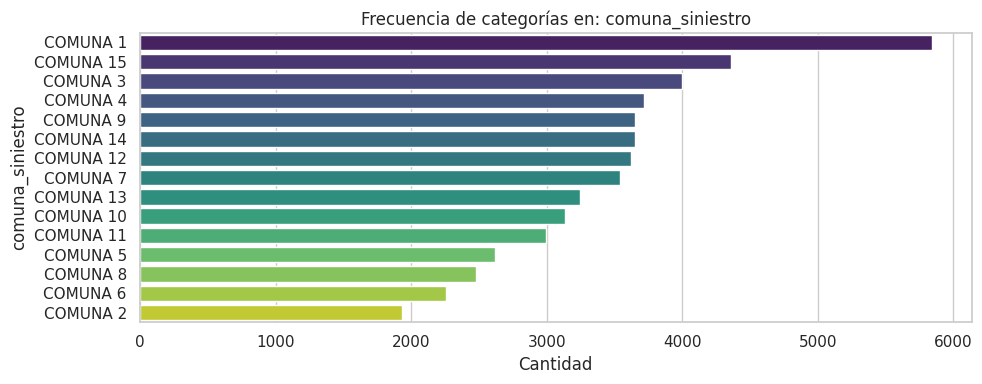

/tmp/ipykernel_4499/2741121550.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], data=df, order=df[col].value_counts().index, palette='viridis')


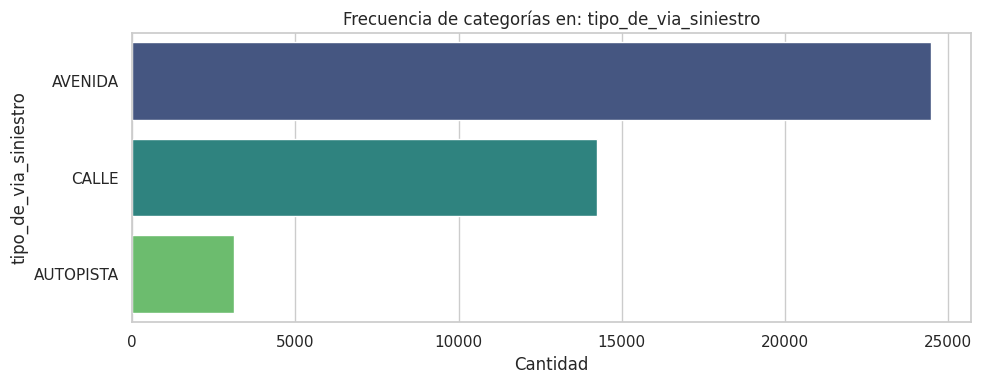

/tmp/ipykernel_4499/2741121550.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], data=df, order=df[col].value_counts().index, palette='viridis')


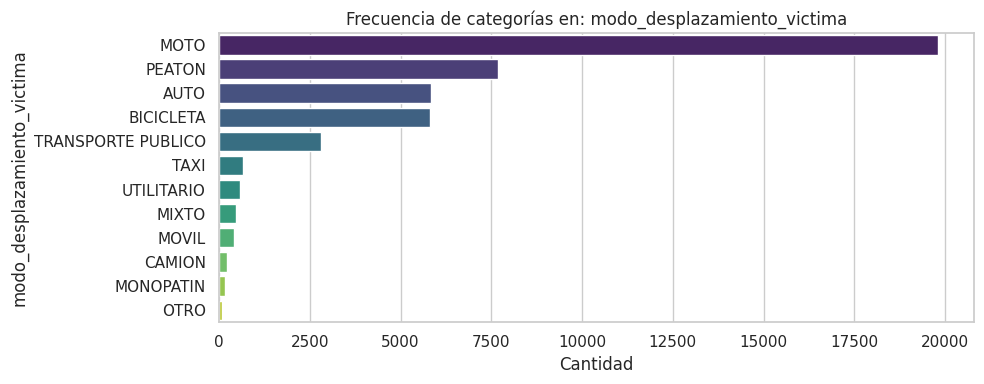

/tmp/ipykernel_4499/2741121550.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], data=df, order=df[col].value_counts().index, palette='viridis')


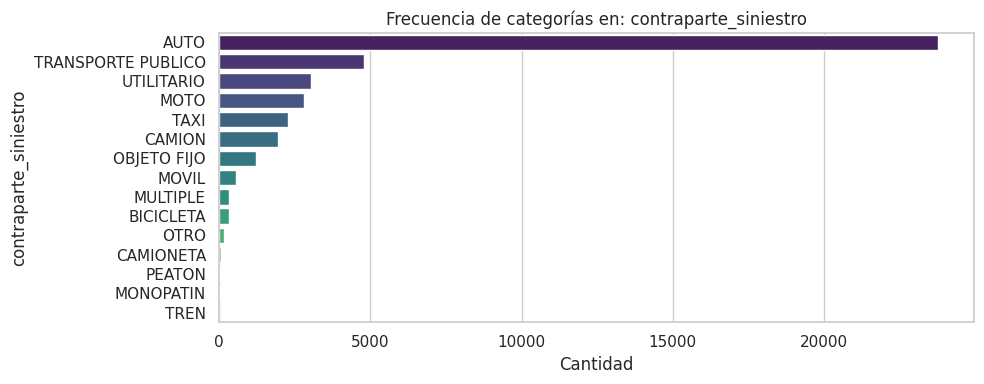

/tmp/ipykernel_4499/2741121550.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], data=df, order=df[col].value_counts().index, palette='viridis')


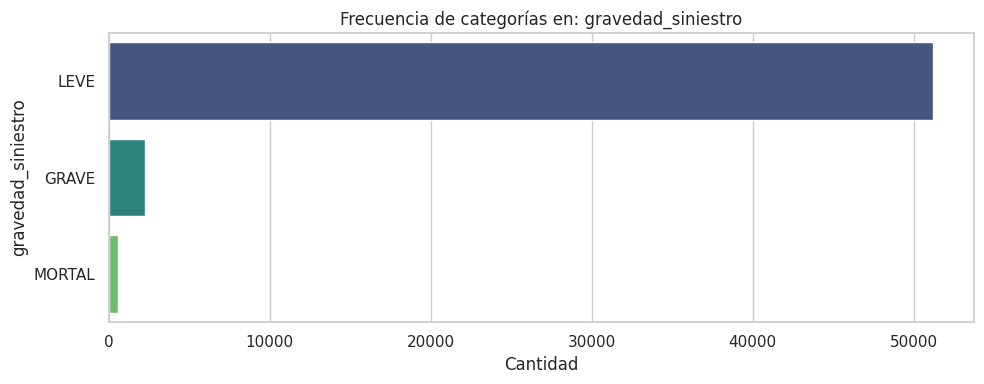

In [15]:
# Configuración estética global para los gráficos
sns.set_theme(style="whitegrid")


# Análisis de Variables Categóricas Clave
print("\n--- ANÁLISIS DE VARIABLES CATEGÓRICAS ---")
columnas_cat_a_graficar = ['comuna_siniestro', 'tipo_de_via_siniestro', 'modo_desplazamiento_victima','contraparte_siniestro','gravedad_siniestro']

analizar_variables_categoricas(df, columnas_cat_a_graficar)

--- ANÁLISIS TEMPORAL: VOLUMEN GENERAL VS. FATALIDAD ---


/tmp/ipykernel_4499/386616442.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  matriz_horaria = df_graficos.groupby(['nombre_dia', 'rango_horario']).size().unstack(fill_value=0)


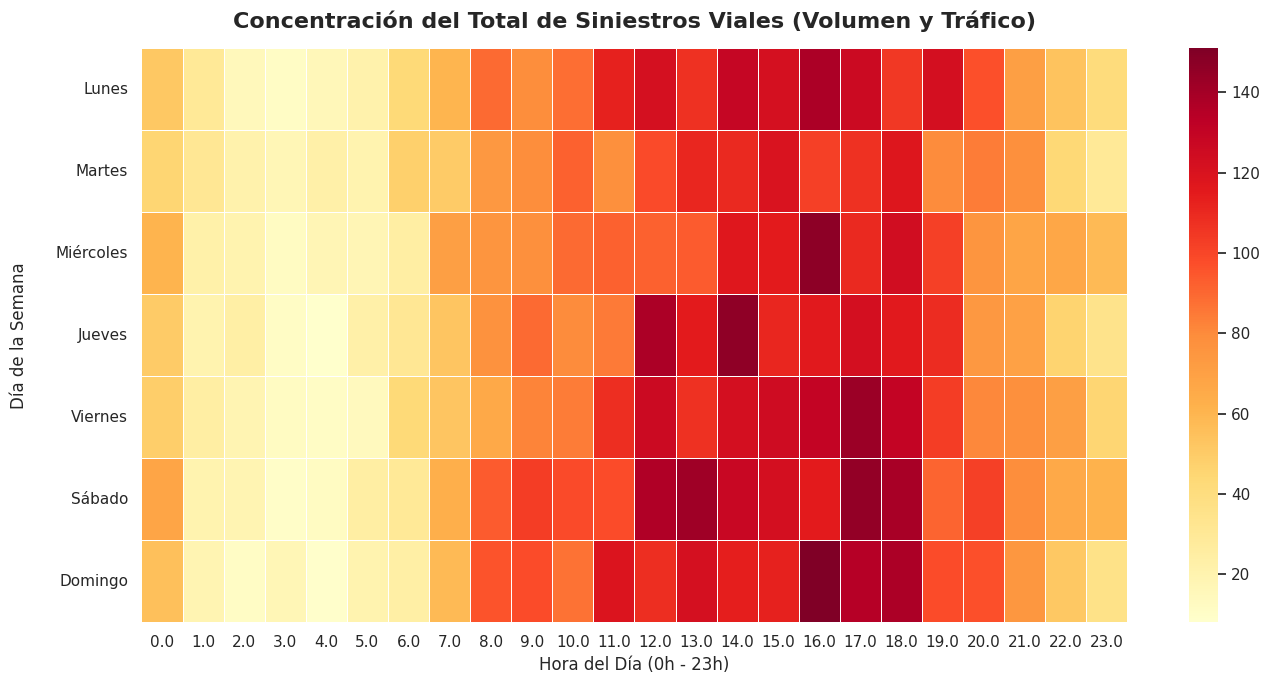

/tmp/ipykernel_4499/386616442.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  matriz_mortal_agrupada = df_mortales.groupby(['nombre_dia', 'franja_horaria']).size().unstack(fill_value=0)


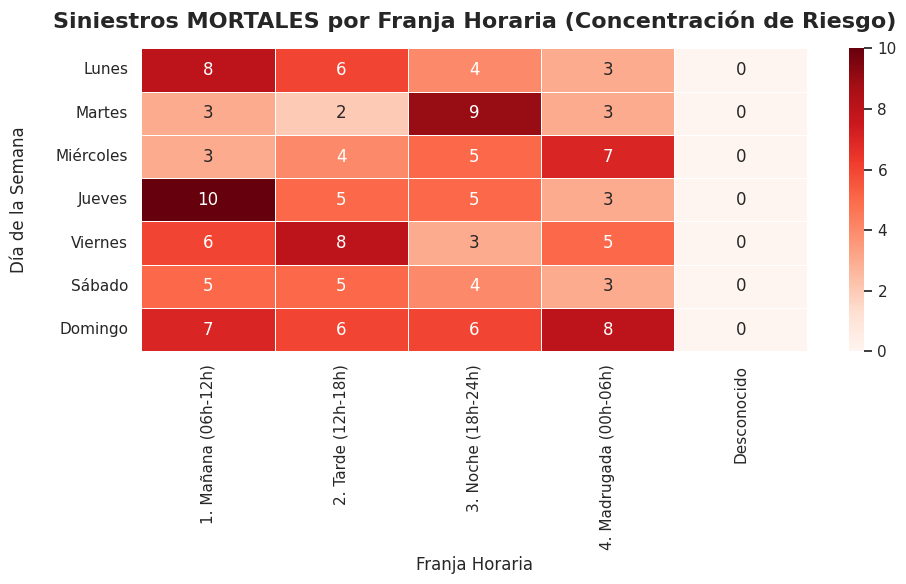

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("--- ANÁLISIS TEMPORAL: VOLUMEN GENERAL VS. FATALIDAD ---")

# ==========================================
# 1. PREPARACIÓN DE DATOS (Se hace una sola vez)
# ==========================================
df_graficos = df.copy()

# A. Mapeo de días de la semana
mapa_dias = {
    7: 'Lunes', 1: 'Martes', 2: 'Miércoles',
    3: 'Jueves', 4: 'Viernes', 5: 'Sábado', 6: 'Domingo'
}
df_graficos['nombre_dia'] = df_graficos['dia_siniestro'].map(mapa_dias)
orden_semana = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
df_graficos['nombre_dia'] = pd.Categorical(df_graficos['nombre_dia'], categories=orden_semana, ordered=True)

# B. Creación de franjas horarias
def categorizar_franja_horaria(hora):
    if pd.isna(hora):
        return 'Desconocido'
    hora = int(hora)
    if 6 <= hora < 12:
        return '1. Mañana (06h-12h)'
    elif 12 <= hora < 18:
        return '2. Tarde (12h-18h)'
    elif 18 <= hora < 24:
        return '3. Noche (18h-24h)'
    else:
        return '4. Madrugada (00h-06h)'

df_graficos['franja_horaria'] = df_graficos['rango_horario'].apply(categorizar_franja_horaria)

# ==========================================
# 2. GRÁFICO 1: VOLUMEN TOTAL (24 HORAS)
# ==========================================
matriz_horaria = df_graficos.groupby(['nombre_dia', 'rango_horario']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 7))
sns.heatmap(matriz_horaria, cmap='YlOrRd', linewidths=0.5, annot=False)
plt.title('Concentración del Total de Siniestros Viales (Volumen y Tráfico)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Hora del Día (0h - 23h)', fontsize=12)
plt.ylabel('Día de la Semana', fontsize=12, labelpad=20)
plt.yticks(rotation=0)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ==========================================
# 3. GRÁFICO 2: FATALIDAD AISLADA (FRANJAS AGRUPADAS)
# ==========================================
df_mortales = df_graficos[df_graficos['gravedad_siniestro'] == 'MORTAL']
matriz_mortal_agrupada = df_mortales.groupby(['nombre_dia', 'franja_horaria']).size().unstack(fill_value=0)

plt.figure(figsize=(10, 6))
sns.heatmap(matriz_mortal_agrupada, cmap='Reds', linewidths=0.5, annot=True, fmt="d")
plt.title('Siniestros MORTALES por Franja Horaria (Concentración de Riesgo)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Franja Horaria', fontsize=12)
plt.ylabel('Día de la Semana', fontsize=12, labelpad=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Análisis de Dinámica Temporal: Volumen General vs. Mortalidad

Al analizar la distribución temporal de los siniestros viales, se evidenció un fenómeno clásico de "ilusión de volumen": las zonas con mayor cantidad de accidentes no coinciden necesariamente con las de mayor letalidad. Para aislar el verdadero riesgo, se contrastó el volumen total (hora a hora) frente a los casos fatales agrupados por franjas horarias, revelando patrones críticos para el modelado predictivo.

### 📌 Hallazgos Principales:

* **El sesgo de la Hora Pico:** El mapa de calor general muestra una alta concentración de siniestros de Lunes a Viernes entre las 12:00h y las 19:00h. Sin embargo, la inmensa mayoría de estos eventos son de gravedad "Leve", producto de la congestión vehicular y bajas velocidades.
* **El Pico de Letalidad Atípico (Jueves por la mañana):** Contrario a la intuición, el mayor foco de accidentes mortales (10 casos) no ocurre durante el fin de semana, sino los Jueves en la franja de 06:00h a 12:00h. Esto sugiere dinámicas de riesgo asociadas al tráfico logístico, laboral matutino o fatiga intersemanal.
* **La Noche del Martes:** Se identificó un segundo foco de alta letalidad los Martes entre las 18:00h y las 24:00h (9 casos), un horario que requiere investigación adicional sobre dinámicas de control o tráfico nocturno.
* **El "Efecto Fin de Semana":** La madrugada del Domingo (00h a 06h) concentra 8 casos mortales. Este comportamiento responde al patrón clásico de riesgo donde convergen calles despejadas, alta velocidad y factores de riesgo en el retorno de salidas nocturnas.

**Impacto en el Modelado:** La alta dispersión y el desbalanceo de clases hacían que la hora exacta (`rango_horario`) generara ruido estadístico en modelos de ensamble. La transformación de esta variable continua en una categórica agrupada (`franja_horaria`) permitirá a los algoritmos (XGBoost, Random Forest) crear reglas de decisión más robustas, penalizando y ajustando las probabilidades de la clase minoritaria en los focos cálidos identificados.

Agregamos la columna franja horaria para luego usarla en los modelos predictivos.

In [30]:
# 1. Definimos la función creadora de franjas (si no estaba en memoria)
def categorizar_franja_horaria(hora):
    if pd.isna(hora):
        return 'Desconocido'
    hora = int(hora)
    if 6 <= hora < 12:
        return '1. Mañana (06h-12h)'
    elif 12 <= hora < 18:
        return '2. Tarde (12h-18h)'
    elif 18 <= hora < 24:
        return '3. Noche (18h-24h)'
    else:
        return '4. Madrugada (00h-06h)'

# 2. La aplicamos PERMANENTEMENTE a tu dataframe principal
df['franja_horaria'] = df['rango_horario'].apply(categorizar_franja_horaria)

print("✅ Columna 'franja_horaria' agregada exitosamente al dataset principal.")

✅ Columna 'franja_horaria' agregada exitosamente al dataset principal.


--- ANÁLISIS DE ASOCIACIÓN CATEGÓRICA (V DE CRAMÉR) ---


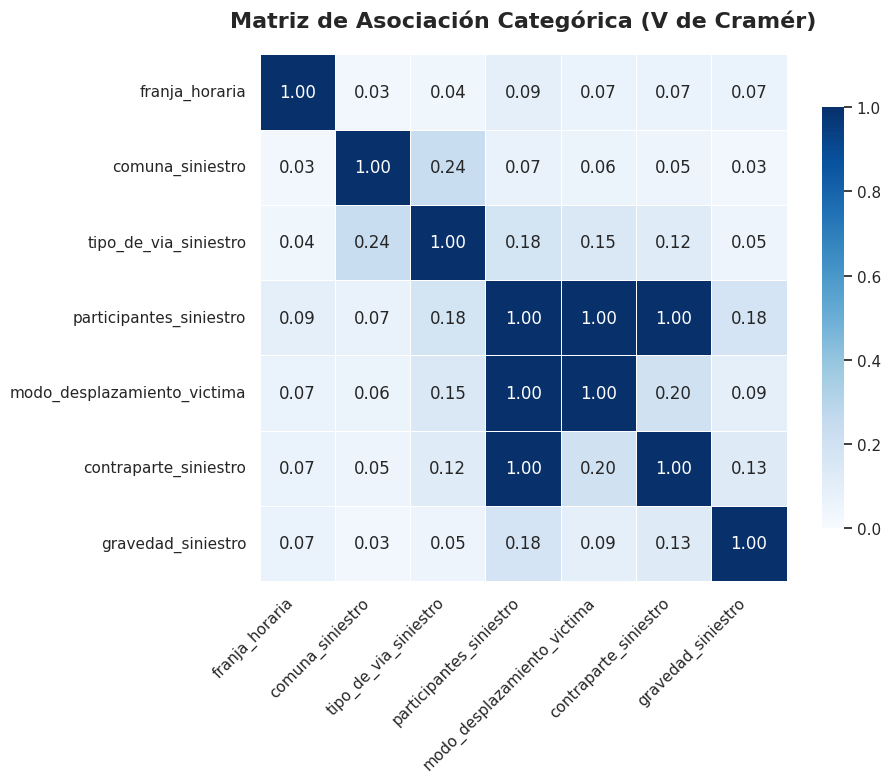


--- IMPACTO SOBRE LA GRAVEDAD DEL SINIESTRO ---
Valores de V de Cramér (0 = Sin relación, 1 = Relación perfecta)


,Correlación con Gravedad
participantes_siniestro,0.177827
contraparte_siniestro,0.127784
modo_desplazamiento_victima,0.090753
franja_horaria,0.065294
tipo_de_via_siniestro,0.051547
comuna_siniestro,0.031318


In [31]:
import pandas as pd
import numpy as np
import scipy.stats as ss
import seaborn as sns
import matplotlib.pyplot as plt

print("--- ANÁLISIS DE ASOCIACIÓN CATEGÓRICA (V DE CRAMÉR) ---")

# 1. FUNCIÓN MATEMÁTICA: V DE CRAMÉR CON CORRECCIÓN DE SESGO
def cramers_v(x, y):
    """Calcula la V de Cramér simétrica entre dos series categóricas."""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape

    # Corrección de sesgo (recomendada para datasets reales)
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)

    # Evita división por cero
    if min((kcorr-1), (rcorr-1)) == 0:
        return 0.0

    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# 2. DEFINICIÓN DE VARIABLES
# Aseguramos que la franja_horaria exista en el dataframe que vamos a usar
# (Asumimos que df_graficos del paso anterior tiene todas estas columnas)
columnas_analisis = [
    'franja_horaria', 'comuna_siniestro', 'tipo_de_via_siniestro',
    'participantes_siniestro', 'modo_desplazamiento_victima',
    'contraparte_siniestro', 'gravedad_siniestro'
]


# Usamos un dropna() rápido aquí para que el cálculo matemático no falle
# Filtramos el dataframe para usar solo las columnas sin nulos problemáticos
df_corr = df[columnas_analisis].dropna()

# 3. CÁLCULO DE LA MATRIZ DE CORRELACIÓN
# Creamos una matriz vacía y la llenamos iterando por cada par de variables
matriz_v = np.zeros((len(columnas_analisis), len(columnas_analisis)))

for i in range(len(columnas_analisis)):
    for j in range(len(columnas_analisis)):
        matriz_v[i, j] = cramers_v(df_corr[columnas_analisis[i]], df_corr[columnas_analisis[j]])

# Convertimos a DataFrame de Pandas para graficar fácilmente
df_cramer = pd.DataFrame(matriz_v, index=columnas_analisis, columns=columnas_analisis)

# ==========================================
# 4. VISUALIZACIÓN: HEATMAP
# ==========================================
plt.figure(figsize=(10, 8))
# Usamos un mapa de colores secuencial (azules) donde más oscuro = mayor asociación
sns.heatmap(df_cramer, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title("Matriz de Asociación Categórica (V de Cramér)", fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ==========================================
# 5. RESULTADO NUMÉRICO: TABLA ORDENADA
# ==========================================
print("\n--- IMPACTO SOBRE LA GRAVEDAD DEL SINIESTRO ---")
print("Valores de V de Cramér (0 = Sin relación, 1 = Relación perfecta)")

# Extraemos solo la columna de la variable objetivo, la ordenamos de mayor a menor y quitamos el 1.0 de sí misma
tabla_impacto = df_cramer['gravedad_siniestro'].sort_values(ascending=False)
tabla_impacto = tabla_impacto.drop('gravedad_siniestro')

# Formateamos como DataFrame para que se vea elegante en la consola de Colab
display(pd.DataFrame(tabla_impacto).rename(columns={'gravedad_siniestro': 'Correlación con Gravedad'}))